# Assignment 3: Class Activation Map
In this assignment we will use the [Class Activation Mapping Technique](http://cnnlocalization.csail.mit.edu/Zhou_Learning_Deep_Features_CVPR_2016_paper.pdf) to demonstrate that object specific spatial information is available in pre-trained image classification networks.

## Introduction:
The final output convolution layers of a trained image classification network contain detailed semantic information about the input image. These feature maps, although low resolution (e.g. 7 x 7) also contain spatial information about the location of the primary object in the image. In the class activation mapping technique we wish to extract this spatial information pertaining to the identified class and overlay this activation on the input image as shown in the figure below.

![](https://github.com/tonyscan6003/etivities/blob/main/cam_img.JPG?raw=true)

* Try to understand the algorithm and plan out the steps required before starting to code.
* The Resnet 50 model has been imported and outputs the last convolution layer and the logits (output of classifier)
* You can display your final results on a 4 x 4 plot.
 * Skeleton code is provided along with a function to unormalise the dataloader images for display.
 * The activation map using a heat map color scheme can be overlaid on the images using matplotlib "alpha" which sets the transparancy of the image e.g. `plt.imshow(class_act_map,cmap=plt.cm.jet,alpha=0.4)`























## HouseKeeping
  Import Packages, set batch size and Size of Images input to network.

In [1]:
from __future__ import absolute_import, division, print_function, unicode_literals
import time
import os
import numpy as np
import glob
import random
import torch
import torch.nn.functional as F
from torch import nn
from torchvision import datasets, models
from torchvision import utils
from torchvision.transforms import ToTensor, v2, Pad, Grayscale
from torchvision.models.feature_extraction import get_graph_node_names
from torchvision.models.feature_extraction import create_feature_extractor
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
from IPython.display import clear_output

In [2]:
# !pip install torchinfo
# !pip install torchmetrics

In [3]:
# Global Variables
HW_trg =224

## Import Dataset

 For this notebook we will use the pytorch [ImageNett dataset](https://pytorch.org/vision/main/generated/torchvision.datasets.Imagenette.html) which contains a sub-set of the ImageNet test dataset with only 10 examples per class. This will be sufficient to demonstrate the Class Activation Mapping algorithm.

The transform is setup without data augmentation and with the required normalisation for the ResNet50 model.

In [4]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
imagenet_data = datasets.Imagenette('/root/INET',download=True,transform=transform)
data_loader = torch.utils.data.DataLoader(imagenet_data,
                                          batch_size=1,
                                          shuffle=True)

Plot a test image from the dataset. The image must be unnormalised and output in the correct form [H,W,C] for display by plt.imshow using `<unnormalise image function>`. (You can re-use this function later to unnormalise images that you will overlay the class activation maps onto.)

In [5]:
import json

# swap out the hard coded labels for a full set of imagenet
# ones, downloaded from https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/refs/heads/master/imagenet-simple-labels.json
imagenette_dict = None
with open('./labels.json') as f:
    imagenette_dict=json.load(f)

mean = [0.485, 0.456, 0.406]  # Example mean used for normalization
std = [0.229, 0.224, 0.225]   # Example std used for normalization

def unnormalize_image(image, mean, std):
    """
    Unnormalize a PyTorch image tensor.

    Args:
        image (torch.Tensor): The normalized image tensor of shape [C, H, W].
        mean (list or tuple): The mean used for normalization.
        std (list or tuple): The standard deviation used for normalization.

    Returns:
        torch.Tensor: The unnormalized image tensor.
    """
    # Remove the batch dimension
    image = image.squeeze(0)

    # Check if the image is in the shape [C, H, W]
    if image.dim() == 3:
        # Unnormalize the image
        for t, m, s in zip(image, mean, std):
            t.mul_(s).add_(m)
    else:
        raise ValueError("Expected image tensor of shape [C, H, W]")

    # Convert from [C, x, y] to [x, y, C]
    image = image.permute(1, 2, 0)

    return image

torch.Size([1, 3, 224, 224])


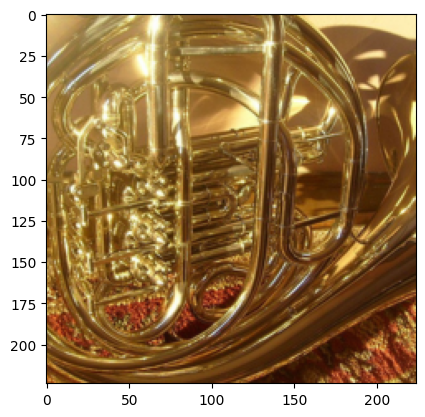

In [6]:
# Verity Dataloader & Image
dataiter = iter(data_loader)
z = next(dataiter)
print(np.shape(z[0]))

img=unnormalize_image(z[0],mean,std)
plt.imshow(img)




# Import Model

This assignment can be completed with CPU runtime as only inference from the model is required. The ResNet50 model is imported for this Assignment. As detailed in the paper a global average pooling layer conected to the classifier layer is required to work. The Resnet50 model satisfies this requirement (without needing modification & retraining)

In [7]:
# Get cpu, gpu or mps device for training.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cpu device


ResNet50 Model is loaded & modified with [create_feature_extraction](https://pytorch.org/vision/stable/feature_extraction.html) to allow output of both logits and feature maps

In [8]:
# Load Model with weights
resnet50 = models.resnet50(pretrained=True)

# Obtain list of graph nodes
train_nodes, eval_nodes = get_graph_node_names(resnet50)
#print(train_nodes)

# Define Dictionary of output nodes
return_nodes={'layer4.2.conv3':'op_features','fc':'op_logits'}

# Create new model using the return nodes
model=create_feature_extractor(resnet50, return_nodes=return_nodes)

c:\Users\shane\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\shane\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [9]:
# Plot Model Summary
from torchinfo import summary
summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Module: 1-5                            --                        --
│    └─Module: 2-1                       --                        --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│ 

Test Passing data through model & verify outputs.

In [10]:
#pass data through model
out=model(z[0])
print([(k, v.shape) for k, v in out.items()])


[('op_features', torch.Size([1, 2048, 7, 7])), ('op_logits', torch.Size([1, 1000]))]


Obtain weights of classifier layer of model from state dictionary

In [11]:
sd = model.state_dict()
for k in sd.keys():
    print(k)
print(np.shape((sd['fc.weight'])))

conv1.weight
bn1.weight
bn1.bias
bn1.running_mean
bn1.running_var
bn1.num_batches_tracked
layer1.0.conv1.weight
layer1.0.bn1.weight
layer1.0.bn1.bias
layer1.0.bn1.running_mean
layer1.0.bn1.running_var
layer1.0.bn1.num_batches_tracked
layer1.0.conv2.weight
layer1.0.bn2.weight
layer1.0.bn2.bias
layer1.0.bn2.running_mean
layer1.0.bn2.running_var
layer1.0.bn2.num_batches_tracked
layer1.0.conv3.weight
layer1.0.bn3.weight
layer1.0.bn3.bias
layer1.0.bn3.running_mean
layer1.0.bn3.running_var
layer1.0.bn3.num_batches_tracked
layer1.0.downsample.0.weight
layer1.0.downsample.1.weight
layer1.0.downsample.1.bias
layer1.0.downsample.1.running_mean
layer1.0.downsample.1.running_var
layer1.0.downsample.1.num_batches_tracked
layer1.1.conv1.weight
layer1.1.bn1.weight
layer1.1.bn1.bias
layer1.1.bn1.running_mean
layer1.1.bn1.running_var
layer1.1.bn1.num_batches_tracked
layer1.1.conv2.weight
layer1.1.bn2.weight
layer1.1.bn2.bias
layer1.1.bn2.running_mean
layer1.1.bn2.running_var
layer1.1.bn2.num_batches_tr

# Class Activion Mapping
You can implement the class activation mapping algorithm in the code cell below.



EXPLANATION
Below are a group of Class Activation Maps for the top 5 classes
predicted by the model. Each class has:

 * CAM based on the final feature maps from the model
 * CAM based on the final feature maps after applying ReLU and normalization
 * The areas where the CAM 2 has stronger activations than CAM1. In reality
   these difference are small and are not to scale with the CAMs which they
   are comparing


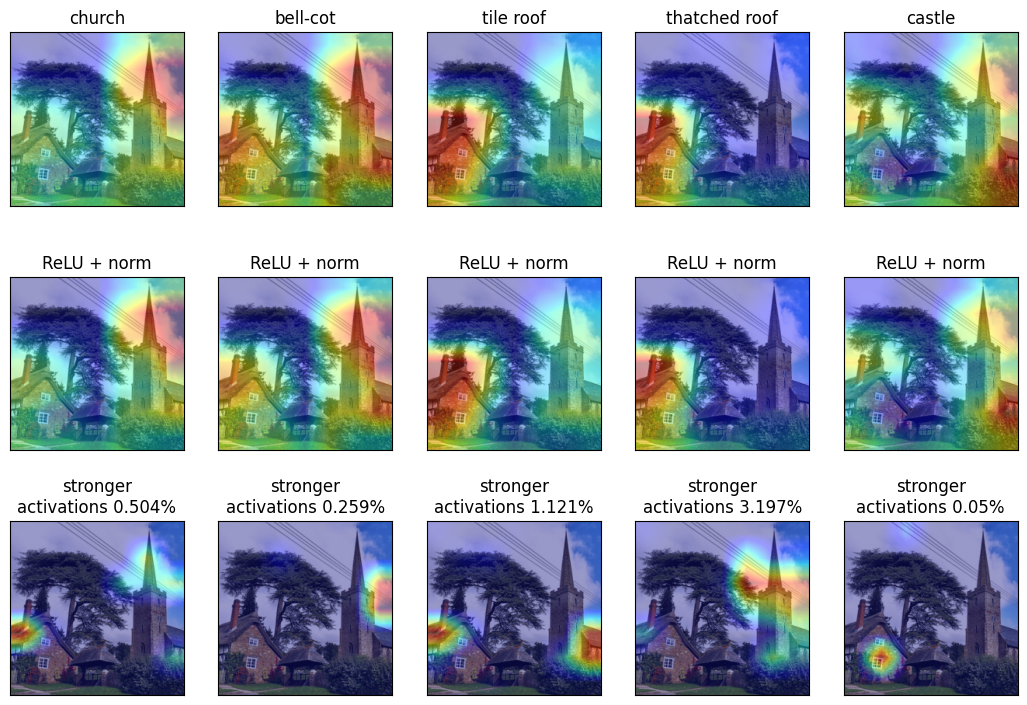

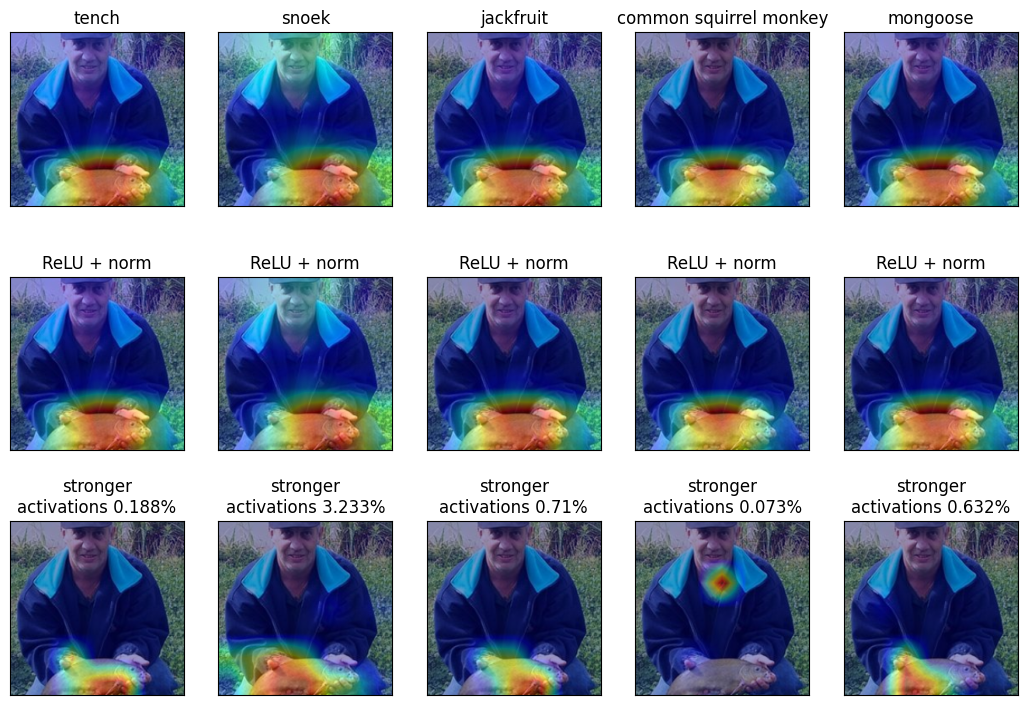

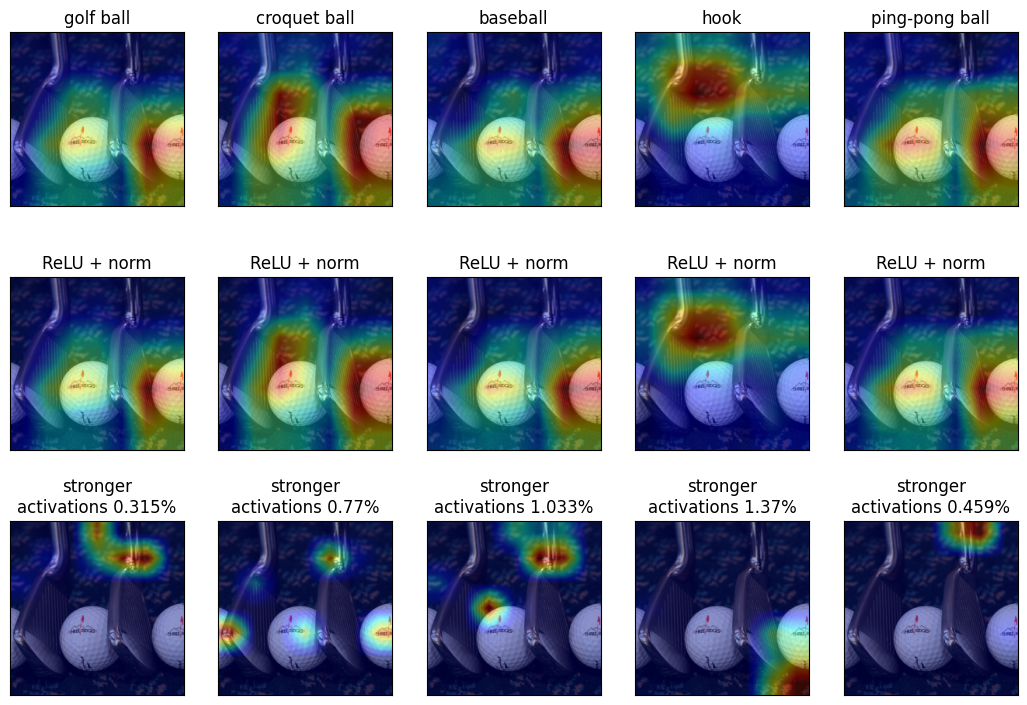

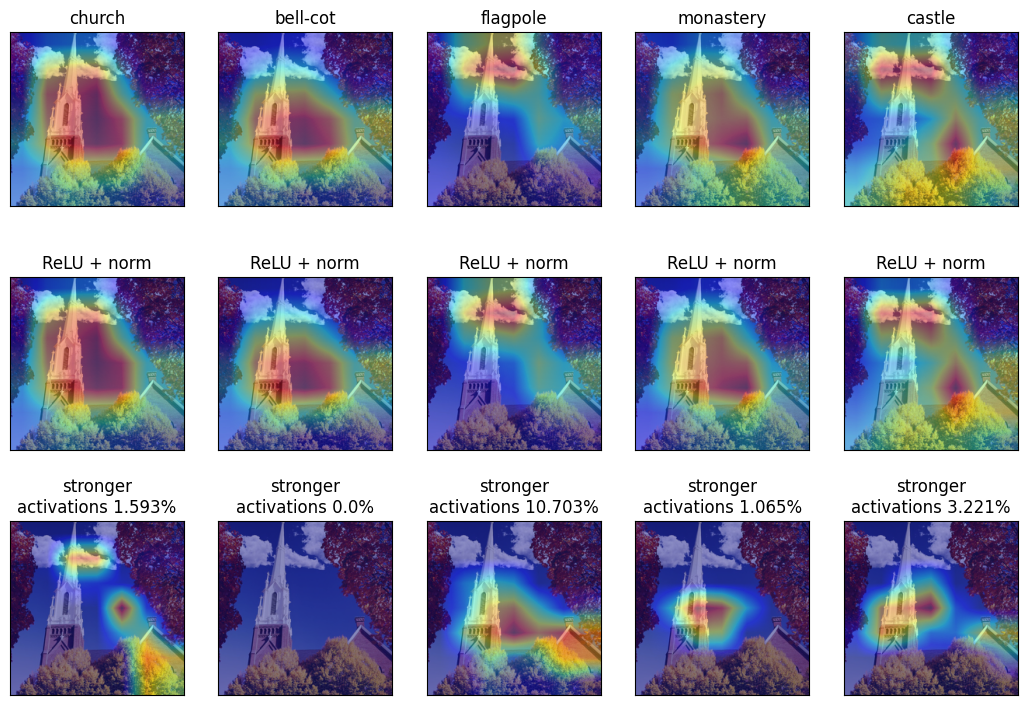

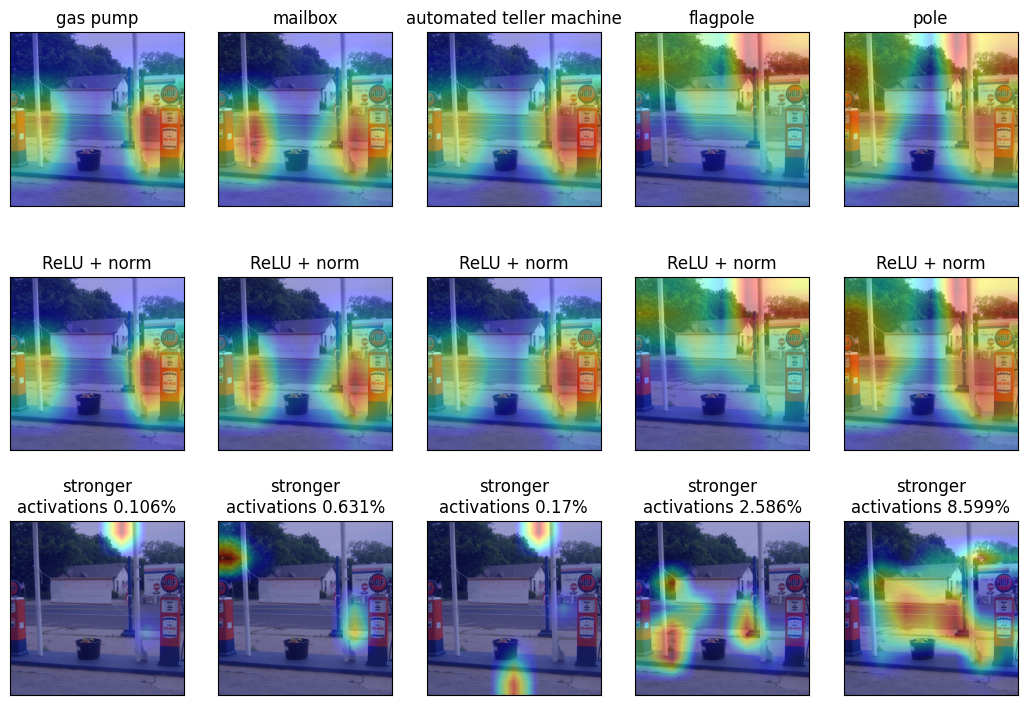

In [91]:

import matplotlib.pyplot as plt
import numpy as np
import math

model_mean = sd['layer4.2.bn3.running_mean']
model_var = sd['layer4.2.bn3.running_var']
model_std = torch.sqrt(model_var)
model.eval()

def display_next():
    # Initialize Figure
    fig = plt.figure(figsize=(13,9), frameon=False)

    ######################################################
    # Your Code here #####################################
    ######################################################
    
    # get the next image
    img, _ = next(dataiter)

    # execute model and get feature_map activations
    model_result = model(img)
    model_activations = model_result["op_features"][0]
    
    # make a second version of activations with ReLU and norm
    model_activations_norm = torch.nn.ReLU()(model_activations)
    model_activations_norm = v2.Normalize(model_mean, model_std)(model_activations_norm)

    # get top 5 class predictions
    _, class_predictions = torch.topk(model_result["op_logits"], 5, dim=1)
    class_predictions = list(map(lambda x: x.item(), class_predictions.squeeze(0)))

    # get image and feature map shapes
    _, _, im_w, im_h = img.shape
    _, maps, map_w, map_h = model_result["op_features"].shape

    # get fc weights for each class
    labels_and_weights = [*map(
        lambda x: (
            imagenette_dict[x],
            sd['fc.weight'][x].unsqueeze(1).unsqueeze(1).expand(maps, map_w, map_h), 
        ),
        class_predictions)]

    img = unnormalize_image(img,mean,std)

    # display an image at a specific index
    def interpolate_and_print(cam, index, label):
        cam = torch.nn.functional\
            .interpolate(cam.unsqueeze(0).unsqueeze(0), (im_w, im_h), mode='bilinear')\
            .squeeze(0)\
            .squeeze(0)\
            .detach()\
            .numpy()

        ax = fig.add_subplot(3, 5, index, xticks=[], yticks=[])
        
        ax.title.set_text(label)
        ax.imshow(img)
        plt.imshow(img)
        plt.imshow(cam, cmap=plt.cm.jet, alpha=0.4)
        
    for col, (label, weights) in enumerate(labels_and_weights):
        # display the cams without ReLU and normalization
        # for the top 5 labels
        cam1 = (model_activations * weights).sum(0)
        interpolate_and_print(cam1, col + 1, label)

        # display the cams with ReLU and normalization
        # for the top 5 labels
        cam2 = (model_activations_norm * weights).sum(0)
        interpolate_and_print(cam2, col + 6, "ReLU + norm")
        
        # normalize the cams so that their activations
        # are comparable
        cam1 = cam1 - cam1.min()
        cam1 = cam1 / cam1.max()
        
        cam2 = cam2 - cam2.min()
        cam2 = cam2 / cam2.max()

        # generate a new CAM which is the difference
        # between the activations on the other 2 CAMs
        diff = cam2 - cam1

        # filter out areas where the ReLU/Norm CAM
        # has weaker activations than the original
        # This will provide less information in the
        # plots, but is is easier to interpret
        diff = torch.nn.ReLU()(diff)
        magnitude = round(100000 * diff.mean().item() / cam1.mean().item()) / 1000

        interpolate_and_print(diff, col + 11, f"stronger\nactivations {magnitude}%")

print("EXPLANATION")
print("Below are a group of Class Activation Maps for the top 5 classes")
print("predicted by the model. Each class has:\n")
print(" * CAM based on the final feature maps from the model")
print(" * CAM based on the final feature maps after applying ReLU and normalization")
print(" * The areas where the CAM 2 has stronger activations than CAM1. In reality")
print("   these difference are small and are not to scale with the CAMs which they")
print("   are comparing")

for _ in range(5): display_next()
plt.show()




# You may Leave a note here explaining your approach/results for the e-moderator.

I found this assignment to be fairly straight forward. In the first versions of this, I simply followed the spec as described

 * Get the final feature maps from the model (`op_features`)
 * Find the top 5 predicted classes (`op_logits`)
 * Multiply the features * the classifier weights (`fc.weight`)
 * Interpolate and print

The only change I made early was to import a full set of class names to make working
with the data set cleaner

## ReLU and Normalization

After seeing Miriam's version I decided to expand the assignment to look into the effect of 
the the final `BatchNorm2d: 3-147` and `ReLU: 3-148` layers on the spacial information. I could have taken them from the model via the `return_nodes`, however in this case I calculated them manually in order to get another opportunity to pull raw data out of the model.

The results were very similar but not exact, and I wanted to display the differences in an easier to see manner.

For this extra display I normalized the 2 CAMS so that they could be compared and generated a new CAM to show areas where the ReLU/Normalized version had stronger positive activations.

For the top 1 class, the results show that these final layers do not really have an effect on positive activations (difference is 0-1%). There was a better result in displaying negative activations, i.e. where the final layers will remove some noise from the image (~10%), however, I decided not to include this in the assignment, as it displays in the opposite way to the other CAMS, and cannot be interpreted as intuitively. Either the viewer would be searching for the blue areas instead of the red areas, or, I could reverse the colour scheme seems even more confusing.

Interestingly, for the less correct predictions the ReLU and batch norm layers do contribute more to incorrect prediction, however, this is only a partial prediction. If more of the diff were displayed you would see that the stronger activations contribute to a wider pattern of interpreting the image incorrectly.
